In [1]:
!pip install scikit-learn



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('Housing_RL.csv')

In [4]:
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.80140,144.99580,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.79960,144.99840,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.80790,144.99340,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.81140,145.01160,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.80930,144.99440,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34852,Yarraville,13 Burns St,4,h,1480000.0,PI,Jas,24/02/2018,6.3,3013.0,...,1.0,3.0,593.0,NaN,NaN,Maribyrnong City Council,-37.81053,144.88467,Western Metropolitan,6543.0
34853,Yarraville,29A Murray St,2,h,888000.0,SP,Sweeney,24/02/2018,6.3,3013.0,...,2.0,1.0,98.0,104.0,2018.0,Maribyrnong City Council,-37.81551,144.88826,Western Metropolitan,6543.0
34854,Yarraville,147A Severn St,2,t,705000.0,S,Jas,24/02/2018,6.3,3013.0,...,1.0,2.0,220.0,120.0,2000.0,Maribyrnong City Council,-37.82286,144.87856,Western Metropolitan,6543.0
34855,Yarraville,12/37 Stephen St,3,h,1140000.0,SP,hockingstuart,24/02/2018,6.3,3013.0,...,NaN,NaN,NaN,NaN,NaN,Maribyrnong City Council,NaN,NaN,Western Metropolitan,6543.0


In [5]:
df.isnull().sum()

Suburb               0
Address              0
Rooms                0
Type                 0
Price             7610
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom2          8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21115
YearBuilt        19306
CouncilArea          3
Lattitude         7976
Longtitude        7976
Regionname           3
Propertycount        3
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.80790,144.99340,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.80930,144.99440,Northern Metropolitan,4019.0
6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra City Council,-37.80720,144.99410,Northern Metropolitan,4019.0
11,Abbotsford,124 Yarra St,3,h,1876000.0,S,Nelson,7/05/2016,2.5,3067.0,...,2.0,0.0,245.0,210.0,1910.0,Yarra City Council,-37.80240,144.99930,Northern Metropolitan,4019.0
14,Abbotsford,98 Charles St,2,h,1636000.0,S,Nelson,8/10/2016,2.5,3067.0,...,1.0,2.0,256.0,107.0,1890.0,Yarra City Council,-37.80600,144.99540,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34847,Wollert,27 Birchmore Rd,3,h,500000.0,PI,Ray,24/02/2018,25.5,3750.0,...,2.0,2.0,383.0,118.0,2016.0,Whittlesea City Council,-37.61940,145.03951,Northern Metropolitan,2940.0
34849,Wollert,35 Kingscote Wy,3,h,570000.0,SP,RW,24/02/2018,25.5,3750.0,...,2.0,2.0,404.0,158.0,2012.0,Whittlesea City Council,-37.61031,145.03393,Northern Metropolitan,2940.0
34853,Yarraville,29A Murray St,2,h,888000.0,SP,Sweeney,24/02/2018,6.3,3013.0,...,2.0,1.0,98.0,104.0,2018.0,Maribyrnong City Council,-37.81551,144.88826,Western Metropolitan,6543.0
34854,Yarraville,147A Severn St,2,t,705000.0,S,Jas,24/02/2018,6.3,3013.0,...,1.0,2.0,220.0,120.0,2000.0,Maribyrnong City Council,-37.82286,144.87856,Western Metropolitan,6543.0


In [8]:
df.isnull().sum()

Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64

In [9]:
df.drop(['Suburb','Address','Date'],axis=1,inplace=True)

In [10]:
df

,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
2,2,h,1035000.0,S,Biggin,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.80790,144.99340,Northern Metropolitan,4019.0
4,3,h,1465000.0,SP,Biggin,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.80930,144.99440,Northern Metropolitan,4019.0
6,4,h,1600000.0,VB,Nelson,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra City Council,-37.80720,144.99410,Northern Metropolitan,4019.0
11,3,h,1876000.0,S,Nelson,2.5,3067.0,4.0,2.0,0.0,245.0,210.0,1910.0,Yarra City Council,-37.80240,144.99930,Northern Metropolitan,4019.0
14,2,h,1636000.0,S,Nelson,2.5,3067.0,2.0,1.0,2.0,256.0,107.0,1890.0,Yarra City Council,-37.80600,144.99540,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34847,3,h,500000.0,PI,Ray,25.5,3750.0,3.0,2.0,2.0,383.0,118.0,2016.0,Whittlesea City Council,-37.61940,145.03951,Northern Metropolitan,2940.0
34849,3,h,570000.0,SP,RW,25.5,3750.0,3.0,2.0,2.0,404.0,158.0,2012.0,Whittlesea City Council,-37.61031,145.03393,Northern Metropolitan,2940.0
34853,2,h,888000.0,SP,Sweeney,6.3,3013.0,2.0,2.0,1.0,98.0,104.0,2018.0,Maribyrnong City Council,-37.81551,144.88826,Western Metropolitan,6543.0
34854,2,t,705000.0,S,Jas,6.3,3013.0,2.0,1.0,2.0,220.0,120.0,2000.0,Maribyrnong City Council,-37.82286,144.87856,Western Metropolitan,6543.0


In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 8887 entries, 2 to 34856
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rooms          8887 non-null   int64  
 1   Type           8887 non-null   str    
 2   Price          8887 non-null   float64
 3   Method         8887 non-null   str    
 4   SellerG        8887 non-null   str    
 5   Distance       8887 non-null   float64
 6   Postcode       8887 non-null   float64
 7   Bedroom2       8887 non-null   float64
 8   Bathroom       8887 non-null   float64
 9   Car            8887 non-null   float64
 10  Landsize       8887 non-null   float64
 11  BuildingArea   8887 non-null   float64
 12  YearBuilt      8887 non-null   float64
 13  CouncilArea    8887 non-null   str    
 14  Lattitude      8887 non-null   float64
 15  Longtitude     8887 non-null   float64
 16  Regionname     8887 non-null   str    
 17  Propertycount  8887 non-null   float64
dtypes: float64(12), int64(1

In [12]:
df.Regionname.value_counts()

Regionname
Southern Metropolitan         2707
Northern Metropolitan         2612
Western Metropolitan          2059
Eastern Metropolitan           982
South-Eastern Metropolitan     371
Northern Victoria               62
Eastern Victoria                51
Western Victoria                43
Name: count, dtype: int64

In [13]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()

In [14]:
lb

LabelEncoder()

In [15]:
df['Regionname']=lb.fit_transform(df.Regionname)

In [16]:
df

,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
2,2,h,1035000.0,S,Biggin,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.80790,144.99340,2,4019.0
4,3,h,1465000.0,SP,Biggin,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.80930,144.99440,2,4019.0
6,4,h,1600000.0,VB,Nelson,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra City Council,-37.80720,144.99410,2,4019.0
11,3,h,1876000.0,S,Nelson,2.5,3067.0,4.0,2.0,0.0,245.0,210.0,1910.0,Yarra City Council,-37.80240,144.99930,2,4019.0
14,2,h,1636000.0,S,Nelson,2.5,3067.0,2.0,1.0,2.0,256.0,107.0,1890.0,Yarra City Council,-37.80600,144.99540,2,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34847,3,h,500000.0,PI,Ray,25.5,3750.0,3.0,2.0,2.0,383.0,118.0,2016.0,Whittlesea City Council,-37.61940,145.03951,2,2940.0
34849,3,h,570000.0,SP,RW,25.5,3750.0,3.0,2.0,2.0,404.0,158.0,2012.0,Whittlesea City Council,-37.61031,145.03393,2,2940.0
34853,2,h,888000.0,SP,Sweeney,6.3,3013.0,2.0,2.0,1.0,98.0,104.0,2018.0,Maribyrnong City Council,-37.81551,144.88826,6,6543.0
34854,2,t,705000.0,S,Jas,6.3,3013.0,2.0,1.0,2.0,220.0,120.0,2000.0,Maribyrnong City Council,-37.82286,144.87856,6,6543.0


In [17]:
df.Type.value_counts()

Type
h    6625
u    1540
t     722
Name: count, dtype: int64

In [18]:
df['Type']=lb.fit_transform(df.Type)

In [19]:
df

,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
2,2,0,1035000.0,S,Biggin,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.80790,144.99340,2,4019.0
4,3,0,1465000.0,SP,Biggin,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.80930,144.99440,2,4019.0
6,4,0,1600000.0,VB,Nelson,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra City Council,-37.80720,144.99410,2,4019.0
11,3,0,1876000.0,S,Nelson,2.5,3067.0,4.0,2.0,0.0,245.0,210.0,1910.0,Yarra City Council,-37.80240,144.99930,2,4019.0
14,2,0,1636000.0,S,Nelson,2.5,3067.0,2.0,1.0,2.0,256.0,107.0,1890.0,Yarra City Council,-37.80600,144.99540,2,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34847,3,0,500000.0,PI,Ray,25.5,3750.0,3.0,2.0,2.0,383.0,118.0,2016.0,Whittlesea City Council,-37.61940,145.03951,2,2940.0
34849,3,0,570000.0,SP,RW,25.5,3750.0,3.0,2.0,2.0,404.0,158.0,2012.0,Whittlesea City Council,-37.61031,145.03393,2,2940.0
34853,2,0,888000.0,SP,Sweeney,6.3,3013.0,2.0,2.0,1.0,98.0,104.0,2018.0,Maribyrnong City Council,-37.81551,144.88826,6,6543.0
34854,2,1,705000.0,S,Jas,6.3,3013.0,2.0,1.0,2.0,220.0,120.0,2000.0,Maribyrnong City Council,-37.82286,144.87856,6,6543.0


In [20]:
df['Method']=lb.fit_transform(df.Method)
df['SellerG']=lb.fit_transform(df.SellerG)
df['CouncilArea']=lb.fit_transform(df.CouncilArea)

In [21]:
df

,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
2,2,0,1035000.0,1,22,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,31,-37.80790,144.99340,2,4019.0
4,3,0,1465000.0,3,22,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,31,-37.80930,144.99440,2,4019.0
6,4,0,1600000.0,4,147,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,31,-37.80720,144.99410,2,4019.0
11,3,0,1876000.0,1,147,2.5,3067.0,4.0,2.0,0.0,245.0,210.0,1910.0,31,-37.80240,144.99930,2,4019.0
14,2,0,1636000.0,1,147,2.5,3067.0,2.0,1.0,2.0,256.0,107.0,1890.0,31,-37.80600,144.99540,2,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34847,3,0,500000.0,0,183,25.5,3750.0,3.0,2.0,2.0,383.0,118.0,2016.0,29,-37.61940,145.03951,2,2940.0
34849,3,0,570000.0,3,180,25.5,3750.0,3.0,2.0,2.0,404.0,158.0,2012.0,29,-37.61031,145.03393,2,2940.0
34853,2,0,888000.0,3,205,6.3,3013.0,2.0,2.0,1.0,98.0,104.0,2018.0,16,-37.81551,144.88826,6,6543.0
34854,2,1,705000.0,1,98,6.3,3013.0,2.0,1.0,2.0,220.0,120.0,2000.0,16,-37.82286,144.87856,6,6543.0


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df.corr()

,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
Rooms,1.000000,-0.557532,0.475074,-0.023840,-0.029918,0.276585,0.084236,0.964465,0.624070,0.401423,0.101158,0.606738,0.006935,-0.137160,0.018758,0.083016,-0.023311,-0.082797
Type,-0.557532,1.000000,-0.363646,0.064818,0.025095,-0.257131,-0.028085,-0.549782,-0.260743,-0.273613,-0.051874,-0.369968,0.267947,0.081268,-0.097183,0.005250,0.060331,0.077880
Price,0.475074,-0.363646,1.000000,-0.009966,-0.059700,-0.231212,0.046033,0.460880,0.463501,0.209464,0.058375,0.507284,-0.313664,-0.124280,-0.224255,0.212174,0.087636,-0.059720
Method,-0.023840,0.064818,-0.009966,1.000000,-0.016097,-0.051133,-0.014290,-0.021186,0.005750,-0.005839,-0.010006,-0.026054,0.009715,0.011845,-0.006638,-0.037411,0.034262,-0.021282
SellerG,-0.029918,0.025095,-0.059700,-0.016097,1.000000,0.022892,-0.001779,-0.031718,-0.037709,0.003871,-0.000433,-0.039489,0.001644,0.025764,0.006708,-0.067982,0.015943,0.055747
Distance,0.276585,-0.257131,-0.231212,-0.051133,0.022892,1.000000,0.489537,0.283460,0.122132,0.259374,0.138559,0.135509,0.313383,-0.129510,-0.055317,0.163941,-0.122144,-0.003247
Postcode,0.084236,-0.028085,0.046033,-0.014290,-0.001779,0.489537,1.000000,0.087286,0.111617,0.055531,0.069623,0.077091,0.089913,0.020197,-0.195081,0.358005,-0.058038,0.032758
Bedroom2,0.964465,-0.549782,0.460880,-0.021186,-0.031718,0.283460,0.087286,1.000000,0.626493,0.405570,0.101035,0.595299,0.016310,-0.136395,0.022745,0.082671,-0.030633,-0.081392
Bathroom,0.624070,-0.260743,0.463501,0.005750,-0.037709,0.122132,0.111617,0.626493,1.000000,0.310962,0.075939,0.553855,0.192914,-0.075309,-0.041859,0.109268,0.015356,-0.058324
Car,0.401423,-0.273613,0.209464,-0.005839,0.003871,0.259374,0.055531,0.405570,0.310962,1.000000,0.123498,0.317593,0.139255,-0.130844,0.015139,0.035589,0.004073,-0.031285


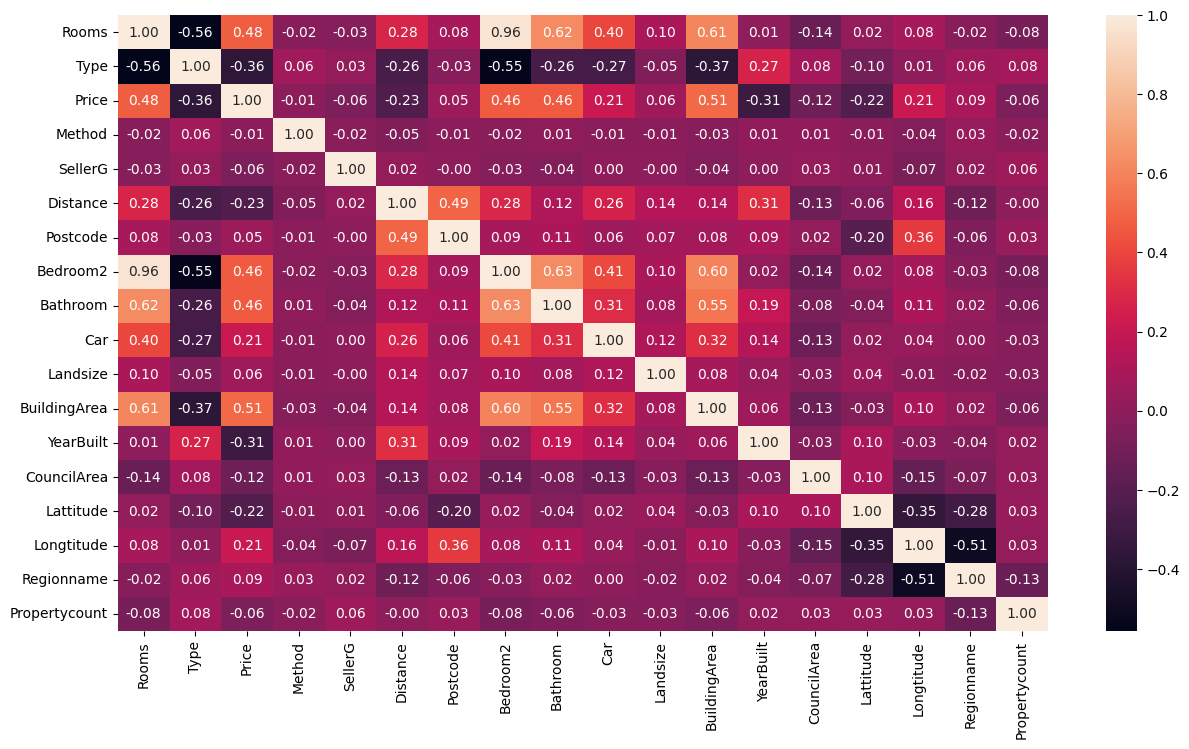

In [24]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(),annot=True,fmt=".2f")
plt.show()

In [25]:
# y== dependent variable it is the target value
# x== independent variable it is the features on which y depends


In [26]:
# data splitting into dependent and independent variable
y=df.Price
x=df.drop('Price',axis=1)

In [27]:
x

,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
2,2,0,1,22,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,31,-37.80790,144.99340,2,4019.0
4,3,0,3,22,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,31,-37.80930,144.99440,2,4019.0
6,4,0,4,147,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,31,-37.80720,144.99410,2,4019.0
11,3,0,1,147,2.5,3067.0,4.0,2.0,0.0,245.0,210.0,1910.0,31,-37.80240,144.99930,2,4019.0
14,2,0,1,147,2.5,3067.0,2.0,1.0,2.0,256.0,107.0,1890.0,31,-37.80600,144.99540,2,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34847,3,0,0,183,25.5,3750.0,3.0,2.0,2.0,383.0,118.0,2016.0,29,-37.61940,145.03951,2,2940.0
34849,3,0,3,180,25.5,3750.0,3.0,2.0,2.0,404.0,158.0,2012.0,29,-37.61031,145.03393,2,2940.0
34853,2,0,3,205,6.3,3013.0,2.0,2.0,1.0,98.0,104.0,2018.0,16,-37.81551,144.88826,6,6543.0
34854,2,1,1,98,6.3,3013.0,2.0,1.0,2.0,220.0,120.0,2000.0,16,-37.82286,144.87856,6,6543.0


In [28]:
y

2        1035000.0
4        1465000.0
6        1600000.0
11       1876000.0
14       1636000.0
           ...    
34847     500000.0
34849     570000.0
34853     888000.0
34854     705000.0
34856    1020000.0
Name: Price, Length: 8887, dtype: float64

In [29]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [30]:
x_train

,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
6865,2,0,1,147,6.9,3039.0,2.0,1.0,0.0,225.0,97.0,1890.0,22,-37.76390,144.90930,6,6232.0
9630,2,2,3,230,6.1,3182.0,2.0,2.0,1.0,0.0,105.0,2009.0,26,-37.86860,144.98120,5,13240.0
23705,4,0,3,112,24.7,3175.0,4.0,2.0,2.0,558.0,109.0,1960.0,9,-37.98046,145.20487,4,10894.0
12554,2,2,1,151,11.4,3163.0,2.0,1.0,1.0,0.0,73.0,1980.0,8,-37.89810,145.06190,5,7822.0
13367,4,0,1,236,14.0,3166.0,4.0,2.0,2.0,537.0,199.0,1920.0,21,-37.91000,145.09600,5,3224.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29140,4,0,2,183,12.4,3107.0,4.0,2.0,2.0,730.0,205.0,1965.0,15,-37.76170,145.10410,0,5420.0
11204,4,0,1,147,9.8,3040.0,4.0,2.0,2.0,740.0,201.0,1950.0,22,-37.75170,144.88730,6,588.0
9135,3,0,3,127,2.1,3205.0,3.0,2.0,0.0,171.0,126.0,1890.0,26,-37.83910,144.95010,5,5943.0
5028,3,0,1,241,13.7,3188.0,4.0,2.0,3.0,373.0,113.0,1984.0,1,-37.93950,145.00880,5,5454.0


In [31]:
x_test

,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
24110,3,0,1,183,14.5,3087.0,3.0,2.0,2.0,664.0,134.0,1952.0,0,-37.70595,145.08493,2,2329.0
5619,4,0,1,138,7.9,3079.0,4.0,1.0,2.0,605.0,181.0,1940.0,0,-37.77070,145.04670,0,5549.0
4538,4,0,4,100,9.2,3146.0,4.0,3.0,4.0,1258.0,254.0,1941.0,2,-37.85520,145.08200,5,10412.0
18931,5,0,1,15,12.4,3108.0,5.0,3.0,2.0,851.0,215.0,1975.0,15,-37.78109,145.13745,0,9028.0
19583,3,0,0,84,18.8,3170.0,3.0,1.0,1.0,744.0,117.0,1960.0,21,-37.93168,145.16126,4,7113.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2537,4,0,1,100,11.7,3125.0,4.0,2.0,1.0,921.0,174.0,1950.0,21,-37.84940,145.12910,5,5678.0
22495,4,0,1,32,16.0,3190.0,4.0,3.0,2.0,616.0,302.0,2005.0,1,-37.94964,145.02753,5,4794.0
13556,3,0,1,15,11.2,3073.0,3.0,1.0,2.0,435.0,102.0,1960.0,6,-37.70540,144.99450,2,21650.0
9211,2,2,2,232,3.3,3141.0,2.0,2.0,2.0,0.0,38.0,2015.0,18,-37.83790,144.99130,5,14887.0


In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler((0,1))

In [33]:
scaler.fit_transform(x_train)

array([[0.11111111, 0.        , 0.25      , ..., 0.44034792, 0.85714286,
        0.27956638],
       [0.11111111, 1.        , 0.75      , ..., 0.50555979, 0.71428571,
        0.60702771],
       [0.33333333, 0.        , 0.75      , ..., 0.70842403, 0.57142857,
        0.49740666],
       ...,
       [0.22222222, 0.        , 0.75      , ..., 0.47735271, 0.71428571,
        0.26606233],
       [0.22222222, 0.        , 0.25      , ..., 0.53059244, 0.71428571,
        0.24321293],
       [0.55555556, 0.        , 1.        , ..., 0.44542701, 0.85714286,
        0.421242  ]], shape=(6220, 17))

In [34]:
scaler.fit_transform(x_test)

array([[0.18181818, 0.        , 0.25      , ..., 0.58178976, 0.28571429,
        0.09124688],
       [0.27272727, 0.        , 0.25      , ..., 0.54057143, 0.        ,
        0.2426979 ],
       [0.27272727, 0.        , 1.        , ..., 0.57863073, 0.71428571,
        0.47142656],
       ...,
       [0.18181818, 0.        , 0.25      , ..., 0.48429111, 0.28571429,
        1.        ],
       [0.09090909, 1.        , 0.5       , ..., 0.48084097, 0.71428571,
        0.68190584],
       [0.18181818, 0.        , 0.25      , ..., 0.36881941, 0.85714286,
        0.09538592]], shape=(2667, 17))

In [35]:
from sklearn.preprocessing import StandardScaler
std_scaler= StandardScaler()

In [36]:
std_scaler.fit_transform(x_train)

array([[-1.1423353 , -0.55294262, -0.39519211, ..., -0.70743146,
         1.10953887, -0.27792208],
       [-1.1423353 ,  2.05160346,  1.33160445, ..., -0.09854641,
         0.62376906,  1.3139855 ],
       [ 0.94286663, -0.55294262,  1.33160445, ...,  1.79560267,
         0.13799924,  0.78107808],
       ...,
       [-0.09973434, -0.55294262,  1.33160445, ..., -0.36191671,
         0.62376906, -0.3435701 ],
       [-0.09973434, -0.55294262, -0.39519211, ...,  0.13518415,
         0.62376906, -0.45464926],
       [ 3.02806856, -0.55294262,  2.19500273, ..., -0.66000786,
         1.10953887,  0.41081419]], shape=(6220, 17))

In [37]:
std_scaler.fit_transform(x_test)

array([[-0.10929386, -0.56422348, -0.39960676, ...,  0.80247397,
        -0.86578008, -1.20536133],
       [ 0.91706783, -0.56422348, -0.39960676, ...,  0.48588242,
        -1.85086348, -0.45819457],
       [ 0.91706783, -0.56422348,  2.15003731, ...,  0.77820996,
         0.61184501,  0.67021287],
       ...,
       [-0.10929386, -0.56422348, -0.39960676, ...,  0.05360203,
        -0.86578008,  3.27787127],
       [-1.13565554,  2.02799704,  0.4502746 , ...,  0.02710208,
         0.61184501,  1.70858903],
       [-0.10929386, -0.56422348, -0.39960676, ..., -0.83331807,
         1.10438671, -1.18494187]], shape=(2667, 17))